# NSynth relative pitch triplet demo

This notebook builds a small contrastive-style triplet sampler on NSynth validation clips. Each example is an interval made from two notes (start → target). Anchor and positive share the same interval and instrument family but start on different MIDI notes; the negative reuses the positive's start note and family with a different interval. Notes are trimmed to 400 ms with a cosine fade-out, and each 2-note clip is exactly 2.0 s.


In [1]:
import json
import math
import random
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple

import torch
import torchaudio
import torch.nn.functional as F
import pandas as pd

from IPython.display import Audio, display

%matplotlib inline
import matplotlib.pyplot as plt

from lightning_scripts.nsynth_triplet_dataset import NsynthTripletDataset

In [2]:
# Instantiate dataset and dataloader
triplet_ds = NsynthTripletDataset(n_examples=500, seed=123, min_midi=40, max_midi=80)

def nsynth_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

triplet_loader = torch.utils.data.DataLoader(
    triplet_ds, batch_size=1, shuffle=False, collate_fn=nsynth_triplet_collate
)
print(f"Triplet dataset ready: {len(triplet_ds)} examples at target_sr={triplet_ds.target_sr}")


Triplet dataset ready: 500 examples at target_sr=20000


In [3]:
# Demo: draw one triplet from the dataset and listen
sample_clips, sample_sr, sample_triplet = triplet_ds[0]
NsynthTripletDataset.describe_triplet(sample_triplet)
for role in ("anchor", "positive", "negative"):
    display(Audio(sample_clips[role].numpy(), rate=sample_sr))


Anchor   | instrument_str guitar_acoustic_010 |  45 →  47 (Δ +2) | ids guitar_acoustic_010-045-075 → guitar_acoustic_010-047-050
Positive | instrument_str guitar_acoustic_010 |  67 →  69 (Δ +2) | ids guitar_acoustic_010-067-025 → guitar_acoustic_010-069-127
Negative | instrument_str guitar_acoustic_010 |  67 →  63 (Δ -4) | ids guitar_acoustic_010-067-025 → guitar_acoustic_010-063-075


## Load pretrained models


In [4]:
# Device and target sample rate for generated clips
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SR = 20_000

# Load 6 pretrained models
import importlib
from lightning_scripts.utils import model_build_utils
importlib.reload(model_build_utils)
from lightning_scripts.utils.model_build_utils import get_model

ssl_lambda_0_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
ssl_lambda_5_config = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only.yaml")
word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")

models = {
    "ssl_lambda_0": get_model(ssl_lambda_0_config, layer_out="relu4"),
    "ssl_lambda_5": get_model(ssl_lambda_5_config, layer_out="relu4"),
    "word": get_model(word_config, supervised=True, layer_out="relu4"),
    "audioset": get_model(audioset_config, supervised=True, layer_out="relu4"),
    "multitask": get_model(multitask_config, supervised=True, layer_out="relu4"),
    "unbal_audioset": get_model(unbal_audioset_config, supervised=True, layer_out="relu4"),
}

for m in models.values():
    m.eval().to(DEVICE)

print(f"Loaded {len(models)} models on {DEVICE}")


Loaded 6 models on cuda


In [5]:
def encode_audio(model, audio_batch: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        z = model(audio_batch)
        if z.ndim > 2:
            z = z.flatten(start_dim=1)
    return z


def distance_metrics_on_triplet(model, clips: Dict[str, torch.Tensor], sr: int) -> Dict[str, float]:
    """Compute simple L2 distances between anchor-positive and anchor-negative."""
    waves = {}
    for k, v in clips.items():
        w = v
        if sr != MODEL_SR:
            w = torchaudio.functional.resample(w.unsqueeze(0), sr, MODEL_SR).squeeze(0)
        waves[k] = w.to(DEVICE)

    # Encode each example separately -- do not pair batch
    anchor_batch = waves["anchor"].unsqueeze(0).unsqueeze(1)
    positive_batch = waves["positive"].unsqueeze(0).unsqueeze(1)
    negative_batch = waves["negative"].unsqueeze(0).unsqueeze(1)

    z_anchor = encode_audio(model, anchor_batch)
    z_pos = encode_audio(model, positive_batch)
    z_neg = encode_audio(model, negative_batch)

    pos_l2 = torch.norm(z_anchor - z_pos, p=2).item()
    neg_l2 = torch.norm(z_anchor - z_neg, p=2).item()

    return {
        "pos_l2": pos_l2,
        "neg_l2": neg_l2,
        "judgement_pos_lt_neg": int(pos_l2 < neg_l2),
    }



In [8]:
from tqdm.auto import tqdm
# Evaluate 6 models on 300 triplets and collect simple L2 stats
all_results = []
for batch_idx, (clips, sr, triplet) in tqdm(enumerate(triplet_loader), total=len(triplet_loader), desc="Evaluating triplets"):
    for name, model in models.items():
        sr_val = int(sr)
        interval = triplet["anchor"]["interval"]
        instrument = triplet["anchor"]["instrument"]
        metrics = distance_metrics_on_triplet(model, clips, sr_val)
        metrics.update({"model": name, "batch_idx": batch_idx, "interval": interval, "instrument": instrument})
        all_results.append(metrics)

results_df = pd.DataFrame(all_results)
display(results_df.head())


Evaluating triplets:   0%|          | 0/500 [00:00<?, ?it/s]

,pos_l2,neg_l2,judgement_pos_lt_neg,model,batch_idx,interval,instrument
0,406.049530,324.002594,0,ssl_lambda_0,0,2,guitar_acoustic_010
1,444.454132,390.394714,0,ssl_lambda_5,0,2,guitar_acoustic_010
2,746.197876,709.129150,0,word,0,2,guitar_acoustic_010
3,611.294189,514.765564,0,audioset,0,2,guitar_acoustic_010
4,576.482483,490.358093,0,multitask,0,2,guitar_acoustic_010


In [9]:
triplet

{'anchor': {'instrument': 'bass_synthetic_009',
  'start_pitch': 64,
  'target_pitch': 74,
  'interval': 10,
  'start_id': 'bass_synthetic_009-064-100',
  'target_id': 'bass_synthetic_009-074-127'},
 'positive': {'instrument': 'bass_synthetic_009',
  'start_pitch': 55,
  'target_pitch': 65,
  'interval': 10,
  'start_id': 'bass_synthetic_009-055-075',
  'target_id': 'bass_synthetic_009-065-075'},
 'negative': {'instrument': 'bass_synthetic_009',
  'start_pitch': 55,
  'target_pitch': 64,
  'interval': 9,
  'start_id': 'bass_synthetic_009-055-075',
  'target_id': 'bass_synthetic_009-064-100'}}

In [10]:
import seaborn as sns
import numpy as np

In [16]:
results_df['family'] = results_df['instrument'].str.split('_').str[0]

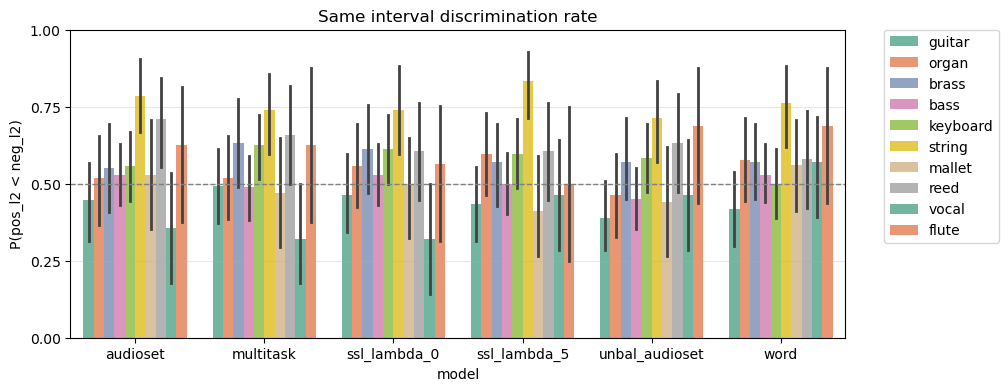

<Figure size 800x400 with 0 Axes>

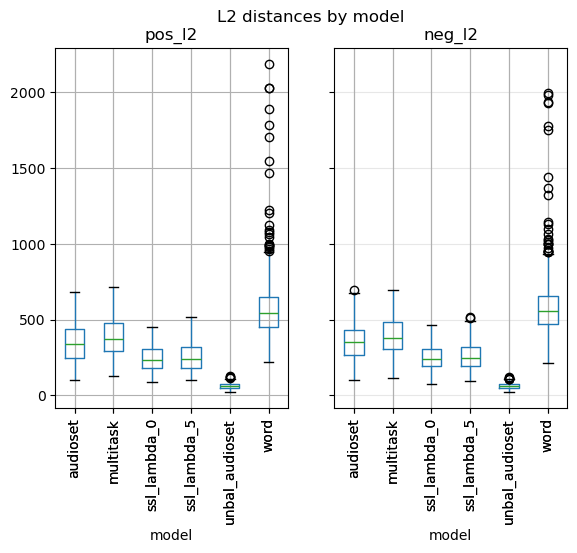

In [18]:
# Plot aggregate results
judgement_rate = results_df.groupby("model")["judgement_pos_lt_neg"].mean()
plt.figure(figsize=(10, 4))
sns.barplot(data=results_df, 
            x="model", 
            y="judgement_pos_lt_neg", 
            hue="family",
            order=judgement_rate.index,
            err_kws={'linewidth': 2},
            # errorbar="ci",
            palette="Set2")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.yticks(np.linspace(0, 1, 5))
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)

plt.ylabel("P(pos_l2 < neg_l2)")
plt.title("Same interval discrimination rate")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
results_df.boxplot(column=["pos_l2", "neg_l2"], by="model", rot=90)
# plt.suptitle("")
plt.suptitle("L2 distances by model")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [139]:
results_df.family.value_counts()

family
string      228
bass        210
mallet      210
flute       186
reed        180
organ       174
brass       174
keyboard    162
guitar      150
vocal       126
Name: count, dtype: int64